# DNV-RP-F105 first-mode free-span screening

This example uses NeqSim's edition-aware `DnvRpF105FreeSpanScreeningKernel` for the current unamended `2025-12` basis. It evaluates a transparent simply supported first mode and current/wave dimensionless groups using a project-controlled structural, environmental, and response-trigger basis.

> **Boundary:** this is a regression-backed `SCREENING` calculation, not a DNV free-span acceptance assessment. The trigger values below are demonstration project inputs, not DNV limits. Soil and span-shoulder stiffness, interacting spans, detailed VIV and direct-wave response, ULS/FLS, fatigue, monitoring, intervention, and conformity remain external.

In [1]:
from pathlib import Path
import os
import sys
import jpype

ROOT = Path.cwd().resolve()
while not (ROOT / 'pom.xml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / 'pom.xml').exists(), 'Run this notebook from the NeqSim repository tree'

if not jpype.isJVMStarted():
    local_classpath = os.environ.get('NEQSIM_NOTEBOOK_CLASSPATH')
    if local_classpath:
        jpype.startJVM(classpath=local_classpath.split(os.pathsep), convertStrings=True)
    else:
        sys.path.insert(0, str(ROOT / 'devtools'))
        from neqsim_dev_setup import neqsim_init
        neqsim_init(project_root=ROOT, recompile=not (ROOT / 'target/classes').exists(), verbose=False)

from jpype import JClass
import pandas as pd
import matplotlib.pyplot as plt
print('Workspace kernel loaded:', ROOT)

Workspace kernel loaded: /workspace/scratch/de313162ffce/repo_f105


## 1. Verified demonstration basis

The steel diameter and wall thickness determine bending stiffness. The hydrodynamic diameter is separate so applicable coatings and marine growth do not corrupt the steel section. Effective modal mass and axial force are controlled external structural inputs; positive force denotes tension and negative force compression.

In [2]:
StandardType = JClass('neqsim.process.mechanicaldesign.designstandards.StandardType')
StandardEdition = JClass('neqsim.process.mechanicaldesign.designstandards.StandardEdition')
Kernel = JClass('neqsim.process.engineering.calculation.DnvRpF105FreeSpanScreeningKernel')
Input = JClass('neqsim.process.engineering.calculation.DnvRpF105FreeSpanScreeningKernel$Input')

edition = StandardEdition.defaultEdition(StandardType.DNV_RP_F105)
kernel = Kernel()

def run_span(span_length_m=30.0, structural_verified=True):
    span_input = (Input.builder(edition, 'Pipeline')
        .spanLengthM(span_length_m)
        .steelOuterDiameterM(0.3239)
        .steelWallThicknessM(0.0206)
        .hydrodynamicDiameterM(0.3239)
        .youngsModulusPa(207.0e9)
        .effectiveMassPerLengthKgPerM(250.0)
        .effectiveAxialForceN(500000.0)
        .currentVelocityMPerS(0.8)
        .waveOrbitalVelocityAmplitudeMPerS(1.2)
        .wavePeriodS(10.0)
        .strouhalNumber(0.2)
        .lockInFrequencyRatioLower(0.8)
        .lockInFrequencyRatioUpper(1.2)
        .maxCurrentReducedVelocityForScreening(4.0)
        .maxWaveReducedVelocityForScreening(3.0)
        .spanGeometryVerified(True)
        .structuralModelVerified(structural_verified)
        .environmentalBasisVerified(True)
        .projectScreeningLimitsVerified(True)
        .build())
    return kernel.calculate(span_input, None)

result = run_span()
assessment = result.getValue()
summary = pd.Series({
    'status': str(result.getStatus()),
    'edition': str(assessment.getStandardEdition()),
    'structural model': str(assessment.toMap().get('structuralModel')),
    'natural frequency [Hz]': float(assessment.getFundamentalNaturalFrequencyHz()),
    'current frequency ratio [-]': float(assessment.getCurrentFrequencyRatio()),
    'current reduced velocity [-]': float(assessment.getCurrentReducedVelocity()),
    'wave reduced velocity [-]': float(assessment.getWaveReducedVelocity()),
    'Keulegan-Carpenter number [-]': float(assessment.getKeuleganCarpenterNumber()),
    'detailed-response triggers': ', '.join(str(item) for item in assessment.getDetailedResponseTriggers()),
    'engineering approval required': bool(assessment.toMap().get('engineeringApprovalRequired')),
})
assert str(result.getStatus()) == 'CALCULATED_REVIEW_REQUIRED'
assert abs(float(assessment.getFundamentalNaturalFrequencyHz()) - 1.0618221449736536) < 1e-12
assert list(map(str, assessment.getDetailedResponseTriggers())) == ['WAVE_REDUCED_VELOCITY']
summary.to_frame('screening result')

,screening result
status,CALCULATED_REVIEW_REQUIRED
edition,DNV-RP-F105 2025-12
structural model,SIMPLY_SUPPORTED_EULER_BERNOULLI_FIRST_MODE
natural frequency [Hz],1.061822
current frequency ratio [-],0.465219
current reduced velocity [-],2.326094
wave reduced velocity [-],3.489141
Keulegan-Carpenter number [-],37.048472
detailed-response triggers,WAVE_REDUCED_VELOCITY
engineering approval required,True


## 2. Span-length sensitivity

The sweep holds every other project input fixed to expose the model response. It is not a design optimization or an allowable-span curve: changing length can also change support conditions, soil stiffness, effective force, mode shape, hydrodynamics, and applicable detailed response methods.

,span length [m],natural frequency [Hz],current reduced velocity [-],wave reduced velocity [-],detailed response required
0,20,2.036000,1.213113,1.819669,False
1,22,1.735104,1.423487,2.135231,False
2,24,1.504766,1.641383,2.462075,False
3,26,1.324149,1.865273,2.797909,False
4,28,1.179587,2.093867,3.140801,True
5,30,1.061822,2.326094,3.489141,True
6,32,0.964401,2.561070,3.841606,True
7,34,0.882712,2.798078,4.197117,True
8,36,0.813393,3.036537,4.554806,True
9,38,0.753941,3.275983,4.913975,True


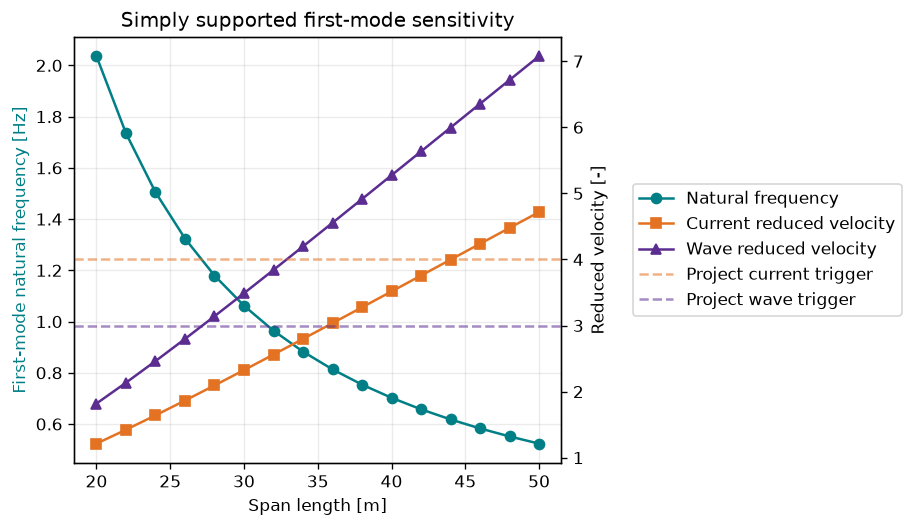

In [3]:
rows = []
for span_length in range(20, 51, 2):
    span_result = run_span(float(span_length))
    value = span_result.getValue()
    rows.append({
        'span length [m]': span_length,
        'natural frequency [Hz]': float(value.getFundamentalNaturalFrequencyHz()),
        'current reduced velocity [-]': float(value.getCurrentReducedVelocity()),
        'wave reduced velocity [-]': float(value.getWaveReducedVelocity()),
        'detailed response required': bool(value.isDetailedResponseAssessmentRequired()),
    })
sweep = pd.DataFrame(rows)
display(sweep)

fig, frequency_axis = plt.subplots(figsize=(8, 4.5))
velocity_axis = frequency_axis.twinx()
frequency_axis.plot(sweep['span length [m]'], sweep['natural frequency [Hz]'], color='#007F86', marker='o', label='Natural frequency')
velocity_axis.plot(sweep['span length [m]'], sweep['current reduced velocity [-]'], color='#E37222', marker='s', label='Current reduced velocity')
velocity_axis.plot(sweep['span length [m]'], sweep['wave reduced velocity [-]'], color='#5C2D91', marker='^', label='Wave reduced velocity')
velocity_axis.axhline(4.0, color='#E37222', linestyle='--', alpha=0.55, label='Project current trigger')
velocity_axis.axhline(3.0, color='#5C2D91', linestyle='--', alpha=0.55, label='Project wave trigger')
frequency_axis.set_xlabel('Span length [m]')
frequency_axis.set_ylabel('First-mode natural frequency [Hz]', color='#007F86')
velocity_axis.set_ylabel('Reduced velocity [-]')
frequency_axis.set_title('Simply supported first-mode sensitivity')
frequency_axis.grid(alpha=0.25)
lines = frequency_axis.get_lines() + velocity_axis.get_lines()
frequency_axis.legend(lines, [line.get_label() for line in lines], loc='center left', bbox_to_anchor=(1.13, 0.5))
fig.tight_layout()
plt.show()

## 3. Fail-closed structural evidence

A numerically complete input is still blocked when the simply supported structural model has not been verified for the surveyed span. The Boolean records the verification state; it is not the verification evidence itself.

In [4]:
blocked = run_span(structural_verified=False)
blockers = [dict(item) for item in blocked.getReadiness().toMap().get('blockers')]
assert str(blocked.getStatus()) == 'BLOCKED'
assert blocked.getValue() is None
pd.DataFrame(blockers)[['code', 'message', 'requiredAction']]

,code,message,requiredAction
0,F105_STRUCTURAL_MODEL_NOT_VERIFIED,The simply supported first-mode beam model has...,"Verify supports, soil stiffness, effective for..."


## Interpretation and next work

Use this result to preserve a reproducible modal/dimensionless screen and decide whether the controlled project workflow must run detailed response analysis. Do not use it to declare a safe or allowable span.

Before engineering acceptance, retain the licensed standard, surveyed geometry, environmental return-period and directionality basis, structural/support model, hydrodynamic model, project trigger source, detailed response and stress results, fatigue/ULS checks, mitigation or monitoring decisions, and accountable approval.